In [2]:
import numpy as np 

data = np.load('pems08.npz')

In [3]:
print(data.files)

['data']


In [4]:
traffic_data = data['data']
print(f"Shape of the data: {traffic_data.shape}")

print(traffic_data[0:2]) 


Shape of the data: (17856, 170, 3)
[[[1.330e+02 6.030e-02 6.580e+01]
  [2.100e+02 5.890e-02 6.960e+01]
  [1.240e+02 3.580e-02 6.580e+01]
  ...
  [7.400e+01 2.131e-01 6.530e+01]
  [9.400e+01 2.260e-02 6.800e+01]
  [6.000e+00 3.100e-03 6.500e+01]]

 [[1.140e+02 5.320e-02 6.690e+01]
  [1.850e+02 5.500e-02 6.850e+01]
  [1.190e+02 3.390e-02 6.500e+01]
  ...
  [7.300e+01 1.469e-01 3.720e+01]
  [8.400e+01 1.890e-02 6.870e+01]
  [4.000e+00 1.800e-03 6.500e+01]]]


In [5]:
missing_values = np.isnan(traffic_data).sum()
print(f"Missing values: {missing_values}")

Missing values: 0


In [ ]:

with open('traffic_data_5min_intervals.csv', 'w') as file:
    file.write('timestep,location,flow,occupy,speed\n')
    
    for timestep in range(traffic_data.shape[0]):
        for location in range(traffic_data.shape[1]):
            flow, occupancy, speed = traffic_data[timestep, location]
            
            file.write(f'{timestep + 1},{location},{flow},{occupancy},{speed}\n')

print("traffic_data_5min_intervals.csv")


traffic_data_5min_intervals.csv


In [9]:
from datetime import datetime, timedelta

# Define the starting date and time
start_datetime = datetime(2016, 7, 1, 0, 0)

with open('traffic_data_with_datetime.csv', 'w') as file:
    file.write('datetime,location,flow,occupy,speed\n')
    
    for timestep in range(traffic_data.shape[0]):
        # Calculate the current datetime for the timestep
        current_datetime = start_datetime + timedelta(minutes=5 * timestep)
        formatted_datetime = current_datetime.strftime('%Y-%m-%d %H:%M:%S')
        
        for location in range(traffic_data.shape[1]):
            flow, occupancy, speed = traffic_data[timestep, location]
            
            # Write the datetime instead of timestep
            file.write(f'{formatted_datetime},{location},{flow},{occupancy},{speed}\n')

print("traffic_data_with_datetime.csv")


traffic_data_with_datetime.csv


In [7]:
import numpy as np
import csv

input_csv = 'traffic_data_5min_intervals.csv'
output_csv = 'traffic.csv'

location_no = 170
no_of_intervals = 24 

with open(output_csv, 'w') as outfile:
    writer = csv.writer(outfile)
    
    writer.writerow(['timestep_2hr', 'location', 'flow', 'occupy', 'speed'])

    with open(input_csv, 'r') as infile:
        reader = csv.reader(infile)
        next(reader)

        timestep_2hr = 0
        location_data = np.zeros((location_no, 3))  
        count = 0  # 24
        for row in reader:
            timestep_5min = int(row[0])
            location = int(row[1])
            flow = float(row[2])
            occupy = float(row[3])
            speed = float(row[4])

            location_data[location, 0] += flow
            location_data[location, 1] += occupy
            location_data[location, 2] += speed

            count += 1

            if count == location_no * no_of_intervals:
                for loc in range(location_no):
                    mean_flow = location_data[loc, 0] / no_of_intervals
                    mean_occupy = location_data[loc, 1] / no_of_intervals
                    mean_speed = location_data[loc, 2] / no_of_intervals

                    writer.writerow([timestep_2hr, loc, mean_flow, mean_occupy, mean_speed])

                timestep_2hr += 1
                location_data.fill(0) 
                count = 0


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('traffic.csv')

print(df.dtypes)

print(df.isna().sum())
print(df.describe())



timestep_2hr      int64
location          int64
flow            float64
occupy          float64
speed           float64
dtype: object
timestep_2hr    0
location        0
flow            0
occupy          0
speed           0
dtype: int64
        timestep_2hr       location           flow         occupy  \
count  126480.000000  126480.000000  126480.000000  126480.000000   
mean      371.500000      84.500000     230.680694       0.065071   
std       214.774955      49.074118     142.786047       0.043110   
min         0.000000       0.000000       0.000000       0.000000   
25%       185.750000      42.000000     112.958333       0.036650   
50%       371.500000      84.500000     217.875000       0.060187   
75%       557.250000     127.000000     331.500000       0.084654   
max       743.000000     169.000000     787.458333       0.543650   

               speed  
count  126480.000000  
mean       63.762996  
std         6.056810  
min         3.079167  
25%        62.629167  
50%

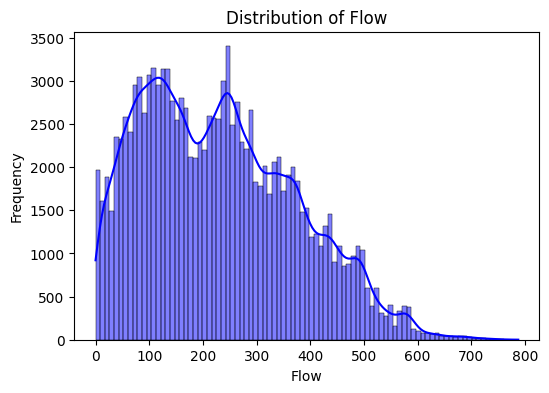

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flow distribution plot
plt.figure(figsize=(6, 4))
sns.histplot(df['flow'], kde=True, color='blue')
plt.title('Distribution of Flow')
plt.xlabel('Flow')
plt.ylabel('Frequency')
plt.show()


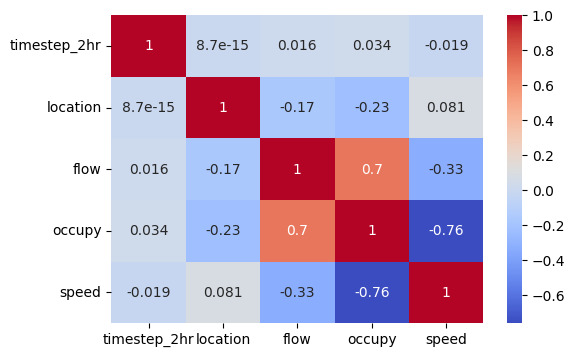

In [22]:
cor = df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.show()


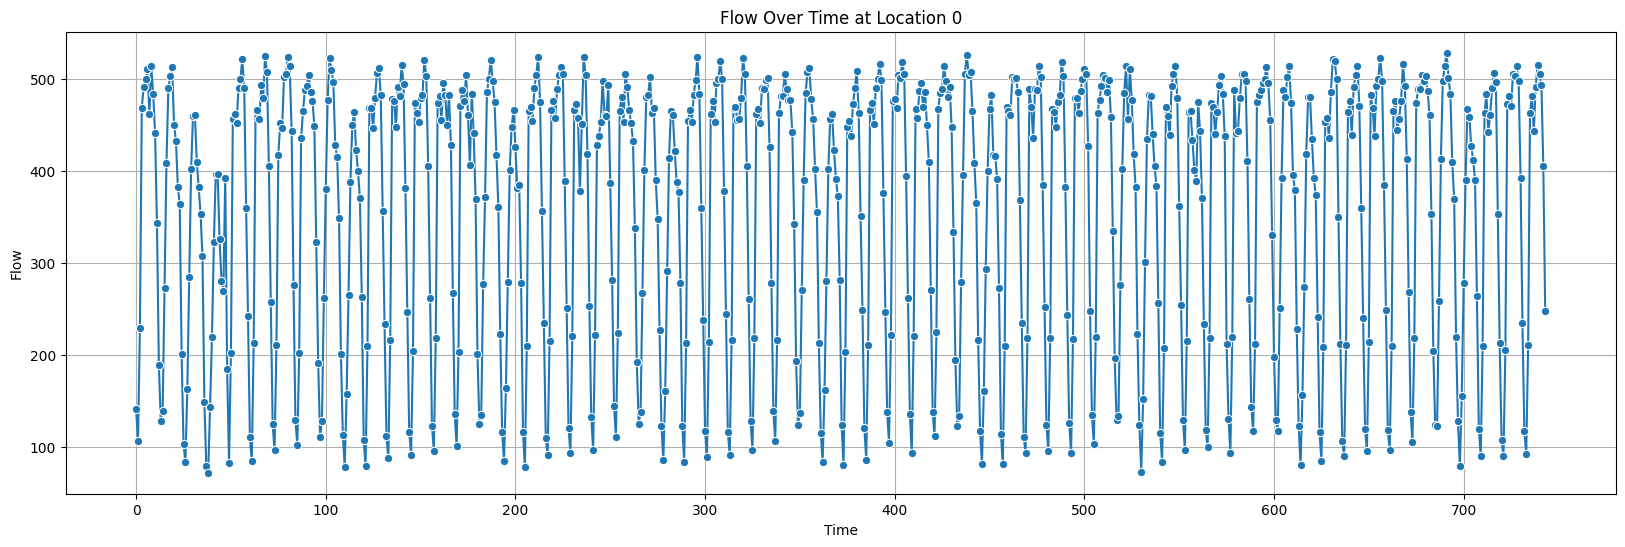

In [30]:
loc = df[df['location'] == 1]

plt.figure(figsize=(20, 6))
sns.lineplot(x='timestep_2hr', y='flow', data=loc, marker='o')
plt.title(f'Flow Over Time at Location 0')
plt.xlabel('Time')
plt.ylabel('Flow')
plt.grid(True)
plt.show()